In [1]:
# single_barrier_1D
import numpy as np
import matplotlib.pyplot as plt
import kwant

from scipy.constants import physical_constants

In [2]:
a = 1.0 * 10**(-9)
a_nm = a*10**9
N = 49
L = (N+1)*a
L_nm = (N+1)*a_nm
print("N=", N)
print("L=",L,"m")
print("L_nm=",L_nm,"nm")
print("a_nm=",a_nm,"nm")

N= 49
L= 5.0000000000000004e-08 m
L_nm= 50.0 nm
a_nm= 1.0 nm


In [3]:
h_bar = physical_constants['Planck constant over 2 pi'][0]
eV_unit = physical_constants['electron volt'][0]
m_el = physical_constants['electron mass'][0]

In [4]:
t = (h_bar**2) / (2*m_el*a**2)
t = t / eV_unit
print("t=",t)

t= 0.03809981988649954


In [5]:
sys = kwant.Builder()
lat = kwant.lattice.chain(a_nm)

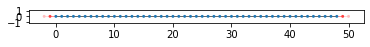

In [6]:
def onsite(site, x0, W0, U0):
    (x,) = site.pos
    if x >= x0 - W0/2 and x <= x0 + W0/2:
        return 2*t + U0
    else:
        return 2*t

for i in range(N):
    sys[lat(i)] = onsite
    
sys[lat.neighbors()] = -t

leadl = kwant.Builder(kwant.TranslationalSymmetry((-a_nm,)))
leadl[lat(0)] = 2*t
leadl[lat.neighbors()] = -t

leadr = leadl.reversed()

sys.attach_lead(leadl)
sys.attach_lead(leadr)

kwant.plot(sys);

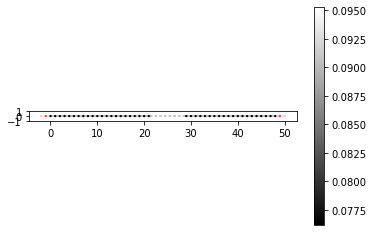

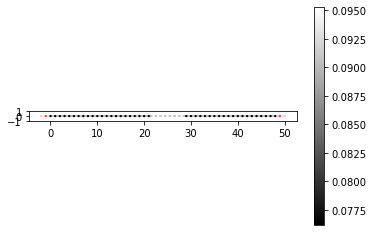

In [21]:
sysf = sys.finalized()
U0p = 0.5*t
x0p = 25
W0p = 6
kwant.plot(sysf, site_color=lambda \
           site:sysf.hamiltonian(site, site,params=dict(U0=U0p,x0=x0p,W0=W0p)))

In [22]:
def calc_T(sysf, E, U0, x0, W0):
    smatrix = kwant.smatrix(sysf, E, params=dict(U0=U0,x0=x0,W0=W0))
    return smatrix.transmission(1, 0)

In [26]:
Emin = 0.0001
Emax = 2*U0p
NE = 100

U0p = 0.5*t
x0p = 25
W0p = 10

Etab = np.linspace(Emin, Emax, NE)
Ttab_p = np.zeros(NE)

U0pp = 0.5*t
x0pp = 25
W0pp = 6

Ttab_pp = np.zeros(NE)

for i in range(NE):
    Ttab_p[i] = calc_T(sysf, Etab[i], U0p, x0p, W0p)
    Ttab_pp[i] = calc_T(sysf, Etab[i], U0pp, x0pp, W0pp)


U0p= 0.01904990994324977


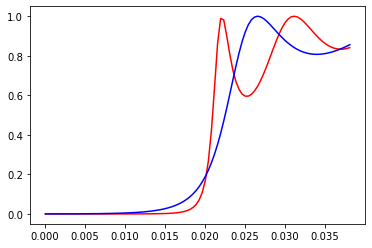

In [28]:
print("U0p=",U0p)
plt.plot(Etab, Ttab_p , "r");
plt.plot(Etab, Ttab_pp, "b");
#plt.ylim(0,0.2)